# A07 Appendix Sparse and Top-k Routing Regimes

LaTeX slot: `fig:appendix-topk-regimes`

This notebook is no longer a generic routing-diagnostics dump.

It focuses on one appendix question:
how do dense soft routing and sparse-like top-k routing differ as operating regimes?

The three panels now emphasize:
1. quality versus active routing breadth,
2. global top-k versus grouped top-k sweeps,
3. cue-space prototypes that explain which behavior cases route differently.

In [24]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import setup_style

setup_style()

topk_tradeoff_df = pd.read_csv(DATA_DIR / 'A07_topk_tradeoff.csv')
topk_sweep_df = pd.read_csv(DATA_DIR / 'A07_topk_sweep.csv')
cue_projection_df = pd.read_csv(DATA_DIR / 'A07_cue_projection.csv')

datasets = ['Beauty', 'KuaiRec', 'Retail Rocket', 'ML-1M']
variant_order = ['dense_global', 'global_top8', 'global_top4', 'global_top2', 'group_dense', 'group_top2', 'group_top1']
variant_label_map = {
    'dense_global': 'Dense soft',
    'global_top8': 'Top-8 global',
    'global_top4': 'Top-4 global',
    'global_top2': 'Top-2 global',
    'group_dense': 'Dense in-group',
    'group_top2': '2 per group',
    'group_top1': '1 per group',
}
setting_order = ['dense_mix', 'top_8', 'top_4', 'top_2', 'dense_in_group', 'top_2_per_group', 'top_1_per_group']
setting_label_map = {
    'dense_mix': 'Dense\nsoft mix',
    'top_8': 'Top-8\nglobal',
    'top_4': 'Top-4\nglobal',
    'top_2': 'Top-2\nglobal',
    'dense_in_group': 'Dense within\ngroups',
    'top_2_per_group': 'Two experts\nper group',
    'top_1_per_group': 'One expert\nper group',
}
family_colors = {
    'Memory': '#C17C74',
    'Tempo': '#2A8C82',
    'Focus': '#5B7C99',
    'Exposure': '#D39C43',
}

### (a) Quality versus active routing breadth

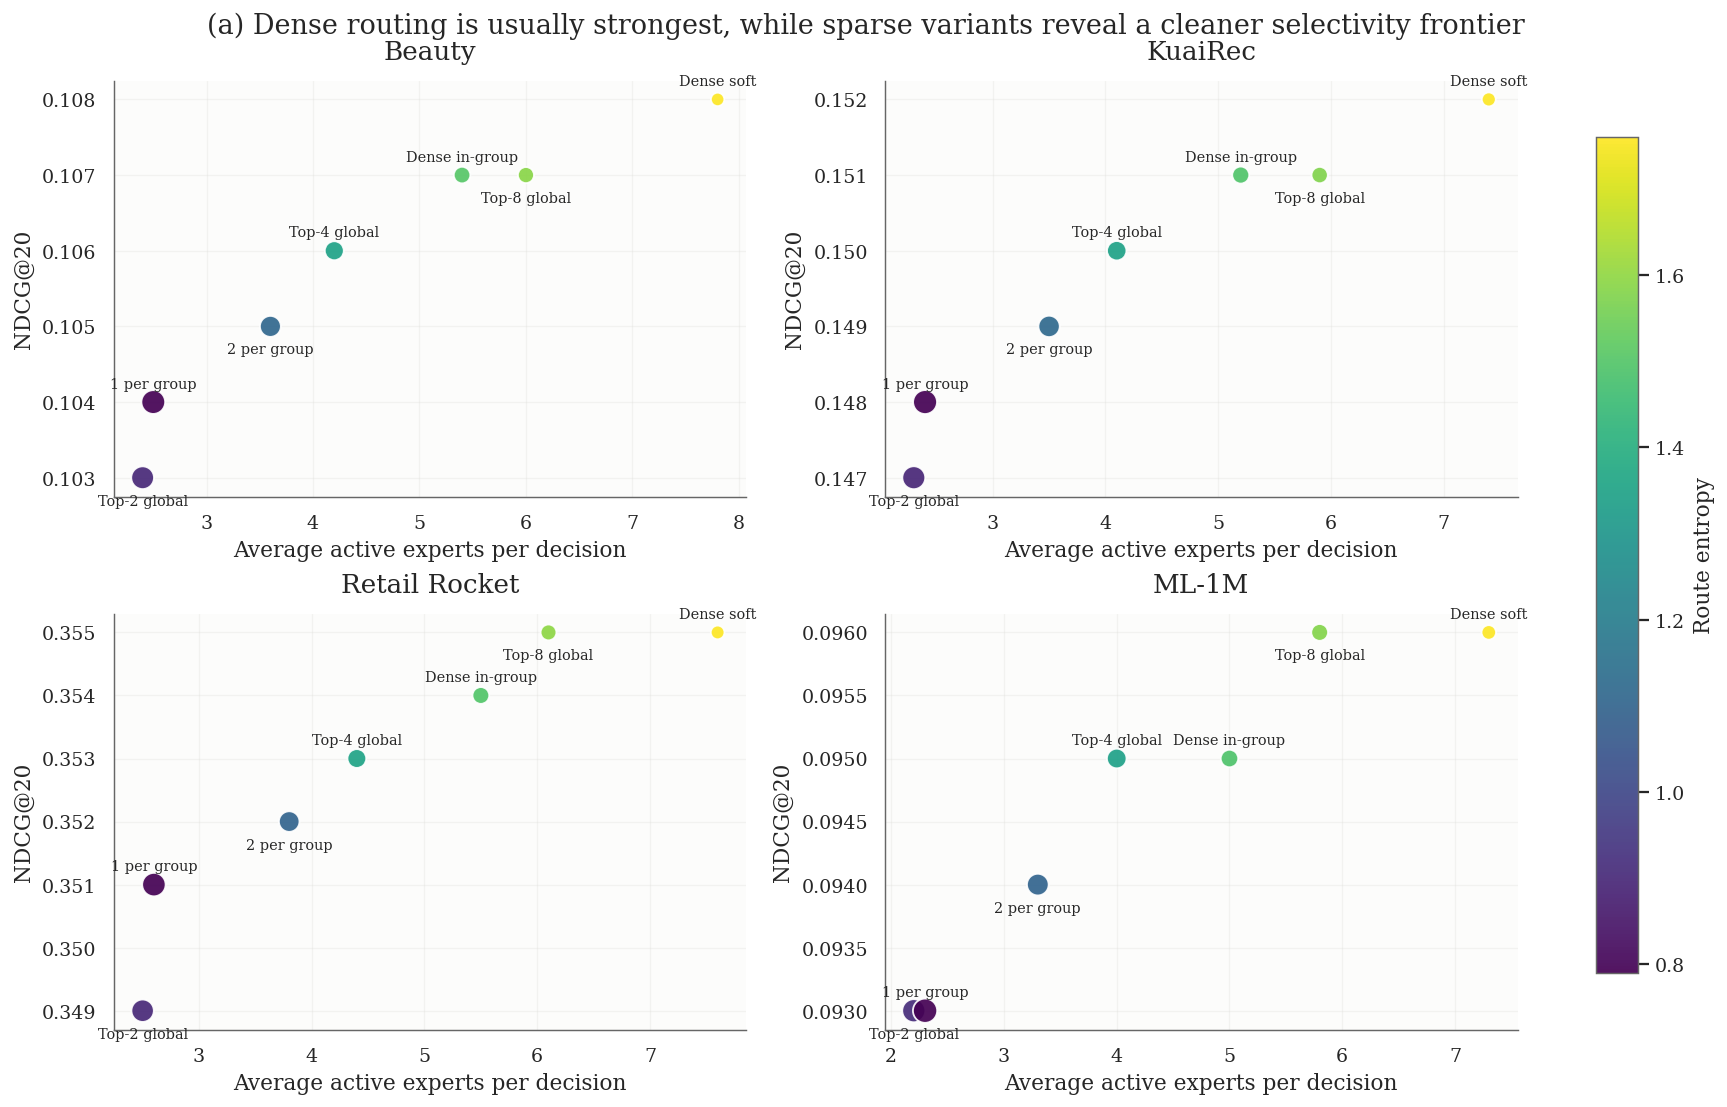

In [25]:
display(Markdown('### (a) Quality versus active routing breadth'))
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.2), constrained_layout=True)
for axis, dataset in zip(axes.flat, datasets):
    subset = topk_tradeoff_df[topk_tradeoff_df['dataset'] == dataset].copy()
    subset['variant'] = pd.Categorical(subset['variant'], categories=variant_order, ordered=True)
    subset = subset.sort_values('variant').reset_index(drop=True)
    scatter = axis.scatter(
        subset['effective_experts'],
        subset['ndcg20'],
        c=subset['route_entropy'],
        s=240 * subset['top_share'],
        cmap='viridis',
        edgecolor='white',
        linewidth=1.0,
        alpha=0.92,
    )
    for idx, row in subset.iterrows():
        y_offset = 8 if idx % 2 == 0 else -15
        axis.annotate(
            variant_label_map[row['variant']],
            (row['effective_experts'], row['ndcg20']),
            textcoords='offset points',
            xytext=(0, y_offset),
            ha='center',
            fontsize=8.0,
        )
    axis.set_title(dataset)
    axis.set_xlabel('Average active experts per decision')
    axis.set_ylabel('NDCG@20')
    axis.grid(alpha=0.25)
colorbar = fig.colorbar(scatter, ax=axes, shrink=0.88)
colorbar.set_label('Route entropy')
fig.suptitle('(a) Dense routing is usually strongest, while sparse variants reveal a cleaner selectivity frontier', y=1.02, fontsize=15)
plt.show()

### (b) Global top-k and grouped top-k should be read as different operating regimes

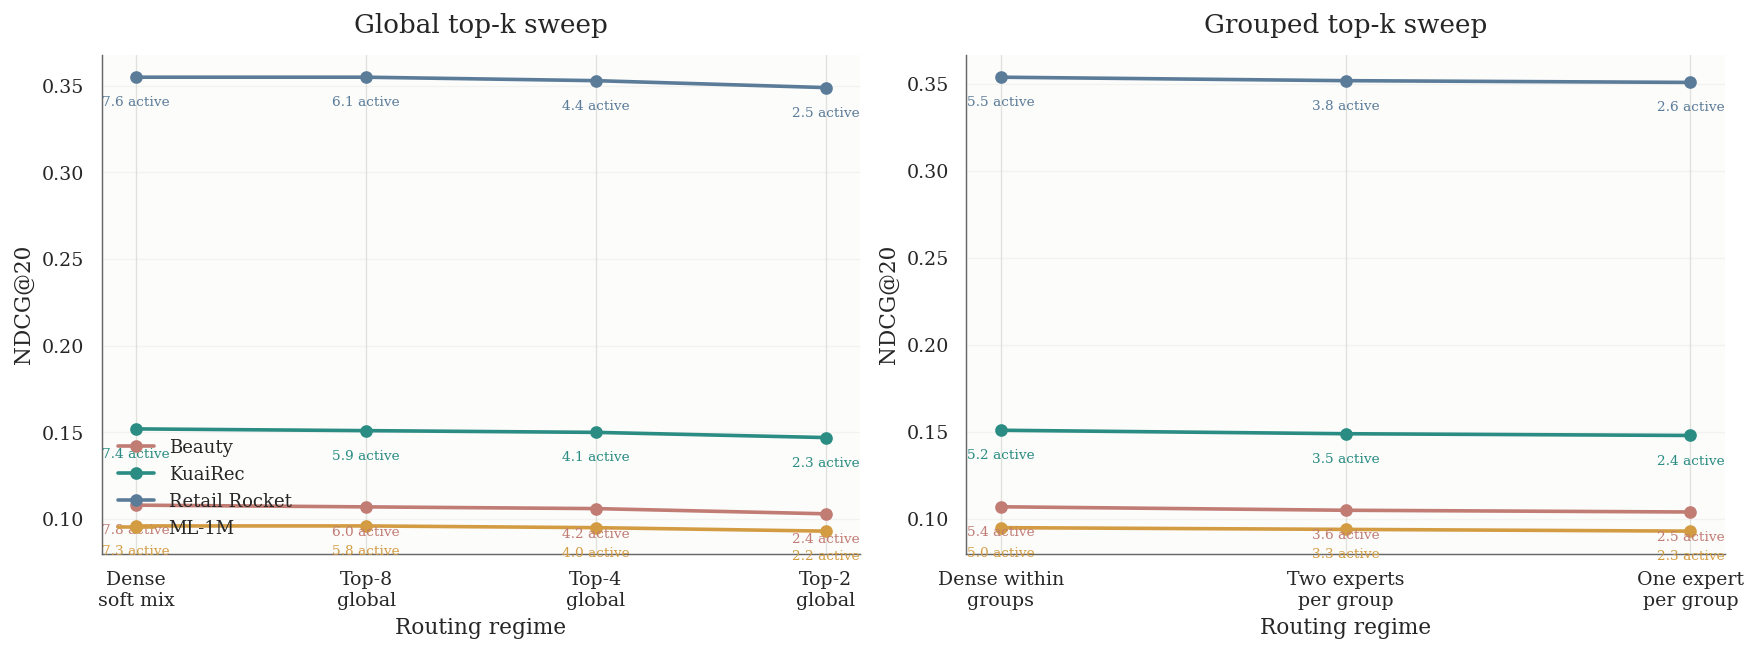

In [ ]:
display(Markdown('### (b) Global top-k and grouped top-k should be read as different operating regimes'))
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9), constrained_layout=True)
mode_to_color = {
    'Beauty': '#C17C74',
    'KuaiRec': '#2A8C82',
    'Retail Rocket': '#5B7C99',
    'ML-1M': '#D39C43',
}
for axis, mode in zip(axes, ['global', 'grouped']):
    mode_subset = topk_sweep_df[topk_sweep_df['mode'] == mode].copy()
    stage_settings = ['dense_mix', 'top_8', 'top_4', 'top_2'] if mode == 'global' else ['dense_in_group', 'top_2_per_group', 'top_1_per_group']
    x = np.arange(len(stage_settings))
    for dataset in datasets:
        subset = mode_subset[mode_subset['dataset'] == dataset].copy()
        subset['setting'] = pd.Categorical(subset['setting'], categories=stage_settings, ordered=True)
        subset = subset.sort_values('setting')
        axis.plot(
            x,
            subset['ndcg20'],
            marker='o',
            linewidth=2.0,
            color=mode_to_color[dataset],
            label=dataset,
        )
    axis.set_xticks(x, [setting_label_map[label] for label in stage_settings])
    axis.set_ylabel('NDCG@20')
    axis.set_xlabel('Routing regime')
    axis.set_title('Global top-k sweep' if mode == 'global' else 'Grouped top-k sweep')
    axis.grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, loc='lower left')
plt.show()

### (c) Behavior prototypes are separable in cue space

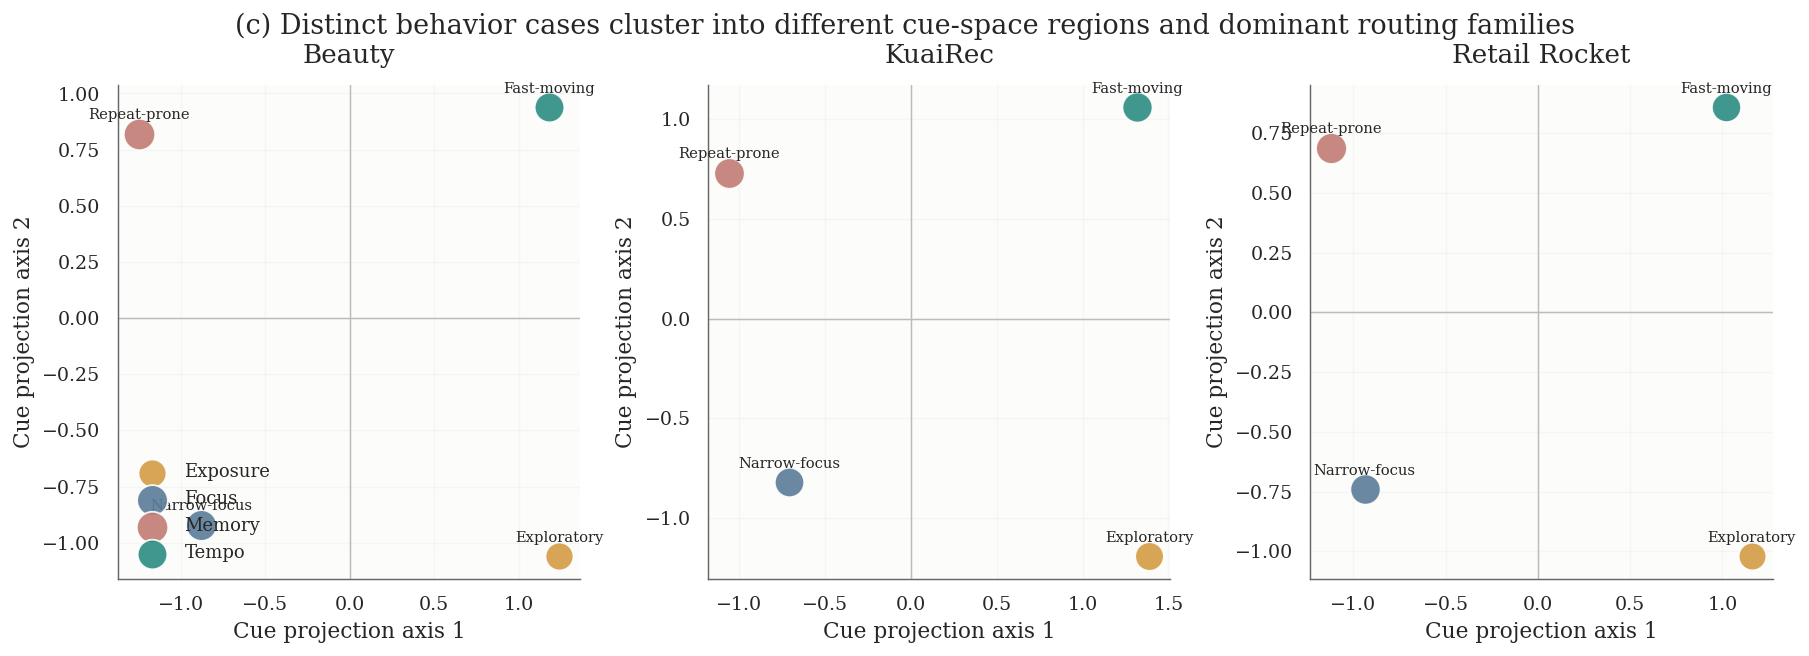

In [18]:
display(Markdown('### (c) Behavior prototypes are separable in cue space'))
fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.7), constrained_layout=True)
for axis, dataset in zip(axes, ['Beauty', 'KuaiRec', 'Retail Rocket']):
    subset = cue_projection_df[cue_projection_df['dataset'] == dataset].copy()
    for family, family_subset in subset.groupby('dominant_family'):
        axis.scatter(
            family_subset['pc1'],
            family_subset['pc2'],
            s=420 * family_subset['route_concentration'],
            color=family_colors[family],
            edgecolor='white',
            linewidth=1.0,
            alpha=0.9,
            label=family,
        )
        for row in family_subset.itertuples():
            axis.annotate(row.slice_name, (row.pc1, row.pc2), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8.2)
    axis.axhline(0, color='#BBBBBB', linewidth=0.8)
    axis.axvline(0, color='#BBBBBB', linewidth=0.8)
    axis.set_title(dataset)
    axis.set_xlabel('Cue projection axis 1')
    axis.set_ylabel('Cue projection axis 2')
    axis.grid(alpha=0.18)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, loc='lower left')
fig.suptitle('(c) Distinct behavior cases cluster into different cue-space regions and dominant routing families', y=1.04, fontsize=15)
plt.show()